# Undertake sensitivity analysis and optimisation

model_optimisation_env

### import packages

In [7]:
%%time

import sys
import os
import numpy as np
import pandas as pd
import scipy as sci
from scipy.stats import gaussian_kde, skew, pearsonr
from scipy.special import expit, logit
from scipy.optimize import differential_evolution
import random

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cmocean.cm as cmo
from cmocean.tools import lighten
import seaborn as sns

import SALib as SAL
from SALib.sample import saltelli
from SALib.analyze import sobol

import sklearn as skl
from sklearn import gaussian_process
from sklearn.gaussian_process.kernels import Matern,WhiteKernel,ConstantKernel,RBF
from sklearn.gaussian_process.kernels import DotProduct,ExpSineSquared,RationalQuadratic
from sklearn.utils import resample
from sklearn.metrics import r2_score

import joblib
from joblib import Parallel, delayed
from multiprocessing import Pool

import emcee

import warnings
warnings.filterwarnings('ignore')

# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("scipy version =", sci.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("sklearn version =", skl.__version__)
print("SALib version =", SAL.__version__)
print("seaborn version =", sns.__version__)
print("emcee version =", emcee.__version__)


wrkdir="/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/"
os.chdir(wrkdir)
os.getcwd()
os.listdir()

python version = 3.10.
numpy version = 1.26.4
pandas version = 2.3.3
scipy version = 1.15.3
matplotlib version = 3.10.6
cmocean version = v3.0.3
sklearn version = 1.7.2
SALib version = 1.4.7
seaborn version = 0.13.2
emcee version = 3.1.6
CPU times: user 2.61 ms, sys: 0 ns, total: 2.61 ms
Wall time: 2.28 ms


['BIAS_optimal.xlsx',
 'BIAS.xlsx',
 'GPR_pco2_cost.joblib',
 'GPR_pco2_rmse.joblib',
 'NSDEV.xlsx',
 'NRMSE_optimal.xlsx',
 'parameter_ranges.xlsx',
 'GPR_chl_bottle_corr.joblib',
 'GPR_bac_corr.joblib',
 'parameter_norm_optimal100_2.txt',
 'parameter_sets_optimal100_2.txt',
 'GPR_micro_corr.joblib',
 'SDEV_opt.xlsx',
 'optimisation_norm_2048.txt',
 'GPR_micro_cost.joblib',
 'GPR_chl_bottle_cost.joblib',
 'parameter_NRMSEpredicted_optimal100_2.txt',
 'apriori_parameter_ranges.xlsx',
 'GPR_fgco2_rmse.joblib',
 'parameter_norm_optimal100_3.txt',
 'CCOEF_opt.xlsx',
 'optimisation_NRMSE.xlsx',
 'GPR_no3.joblib',
 'GPR_poc_cost.joblib',
 'GPR_sil.joblib',
 'GPR_sil_cost.joblib',
 'GPR_fgco2.joblib',
 'SDEV.xlsx',
 'GPR_pco2.joblib',
 'mcmc_wombat_mid_26params_1M_rmse_withSIL.h5',
 'CCOEF_optimal.xlsx',
 'mcmc_wombat_mid_26params_1M_rmse.h5',
 'GPR_sil_rmse.joblib',
 'GPR_fgco2_cost.joblib',
 'NSDEV_optimal.xlsx',
 'GPR_chl_bottle_rmse.joblib',
 'GPR_b1mb2.joblib',
 'NRMSE.xlsx',
 'CCOEF.xl

### read in the normalised parameter sets that were used as input for the forward model runs

In [8]:
%%time
X = pd.read_excel('optimisation_norm_2048.xlsx', header=0, usecols=lambda column: column != 'Unnamed: 0')
param_names = X.columns
X

CPU times: user 905 ms, sys: 22.4 ms, total: 928 ms
Wall time: 976 ms


,alphabio_phy,abioa_phy,bbioa_phy,abioa_dia,bbioh,phykf,phymaxqc,phylmor,diamaxqs,diaVmaxs,...,dfefloor,kscav_dfe,kcoag_dfe,bsi_alpha,aoalmor,pbac_alpha,lbac_alpha,lbac_beta,baclmor,bacqmor
0,0.987100,0.802393,0.011476,0.175775,0.829965,0.020376,0.028623,0.305757,0.718250,0.069816,...,0.527124,0.495471,0.720470,0.593533,0.445824,0.587362,0.664433,0.679876,0.602062,0.528348
1,0.341358,0.455172,0.548290,0.749641,0.166952,0.772848,0.599865,0.753054,0.272433,0.862796,...,0.182645,0.747969,0.411361,0.237721,0.783908,0.203196,0.483653,0.417205,0.299420,0.354694
2,0.094463,0.512349,0.474828,0.320280,0.315509,0.602780,0.483372,0.741658,0.209961,0.502574,...,0.915068,0.070601,0.978138,0.424727,0.719229,0.495409,0.829110,0.813653,0.948049,0.833059
3,0.703117,0.229599,0.965377,0.761387,0.679701,0.354031,0.896444,0.200492,0.780740,0.303100,...,0.259547,0.827136,0.169333,0.779548,0.010021,0.861494,0.021612,0.080234,0.141436,0.034419
4,0.500264,0.747794,0.701410,0.979139,0.512214,0.151958,0.319095,0.541145,0.004129,0.884495,...,0.784571,0.296986,0.071565,0.272982,0.881594,0.016933,0.367801,0.139360,0.776262,0.203577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,0.500916,0.228187,0.465828,0.587874,0.319375,0.804039,0.301653,0.523485,0.748457,0.621103,...,0.820314,0.110550,0.000947,0.317737,0.747823,0.416871,0.457503,0.910349,0.412093,0.866723
2044,0.702426,0.749083,0.202837,0.680606,0.487824,0.693635,0.976384,0.249402,0.473800,0.191302,...,0.346314,0.515451,0.223471,0.824791,0.360621,0.696889,0.182598,0.867854,0.546675,0.879695
2045,0.093811,0.024114,0.739284,0.238950,0.508421,0.443299,0.403189,0.692732,0.543633,0.991308,...,0.939825,0.259176,0.906420,0.468994,0.901825,0.063456,0.997899,0.105133,0.365062,0.237295
2046,0.341035,0.943408,0.283498,0.825172,0.970210,0.183267,0.519925,0.797906,0.981114,0.631087,...,0.203498,0.934347,0.481001,0.157933,0.587635,0.355119,0.316016,0.626654,0.888202,0.699970


### read in the performance metrics of each experiment (RMSE and correlation)

In [9]:
%%time

print(os.getcwd())

### RMSE
rmse = pd.read_excel("output/optimisation_RMSE.xlsx", header=0)
### std
sdev = pd.read_excel("output/optimisation_SDEV.xlsx", header=0)
### correlations
corr = pd.read_excel("output/optimisation_CCOEF.xlsx", header=0)
### nstd
nsdev = pd.read_excel("output/optimisation_NSDEV.xlsx", header=0)

rmse.columns = rmse.columns.str[0:-5]
sdev.columns = sdev.columns.str[0:-5]
corr.columns = corr.columns.str[0:-6]
nsdev.columns = nsdev.columns.str[0:-6]

print(corr.min(axis=0), corr.max(axis=0))
print(nsdev.min(axis=0), nsdev.max(axis=0))
print(sdev.min(axis=0), sdev.max(axis=0))
print(rmse.min(axis=0), rmse.max(axis=0))



/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data
pco2           -0.979760
fgco2          -0.966519
nh4            -0.566765
no3            -0.215275
sil             0.017255
dfe            -0.564719
poc            -0.314830
bac            -0.994008
micro          -0.879606
meso           -0.783838
chl_bottle     -0.185102
chl_mooring    -0.959870
b1mb2          -0.970142
D2L300mD2L50   -0.880734
sum            -4.866324
dtype: float64 pco2            0.978560
fgco2           0.949635
nh4             0.546344
no3             0.231252
sil             0.149926
dfe             0.686958
poc             0.732064
bac             0.989388
micro           0.950776
meso            0.911760
chl_bottle      0.098034
chl_mooring     0.977194
b1mb2           0.955279
D2L300mD2L50    0.983126
sum             4.977841
dtype: float64
pco2            5.110816e-02
fgco2           1.518578e-01
nh4             7.757125e-07
no3             2.233725e-02
sil             1.810147e-01
dfe             1.788

### create the cost function

In [10]:
len(rmse)

2048

In [11]:

### solve for the observational standard deviation using the normalised standard deviation
obs_std = sdev / nsdev

### calculate the cost function, penalizing experiments where the correlations are very poor
nrmse = (rmse/obs_std)
cost = (1 - corr) * nrmse

targets = rmse.columns
targets

Index(['pco2', 'fgco2', 'nh4', 'no3', 'sil', 'dfe', 'poc', 'bac', 'micro',
       'meso', 'chl_bottle', 'chl_mooring', 'b1mb2', 'D2L300mD2L50', 'sum'],
      dtype='object')

### check out the distributions of the RMSE, the correlation and the cost function

(0.0, 10.0)

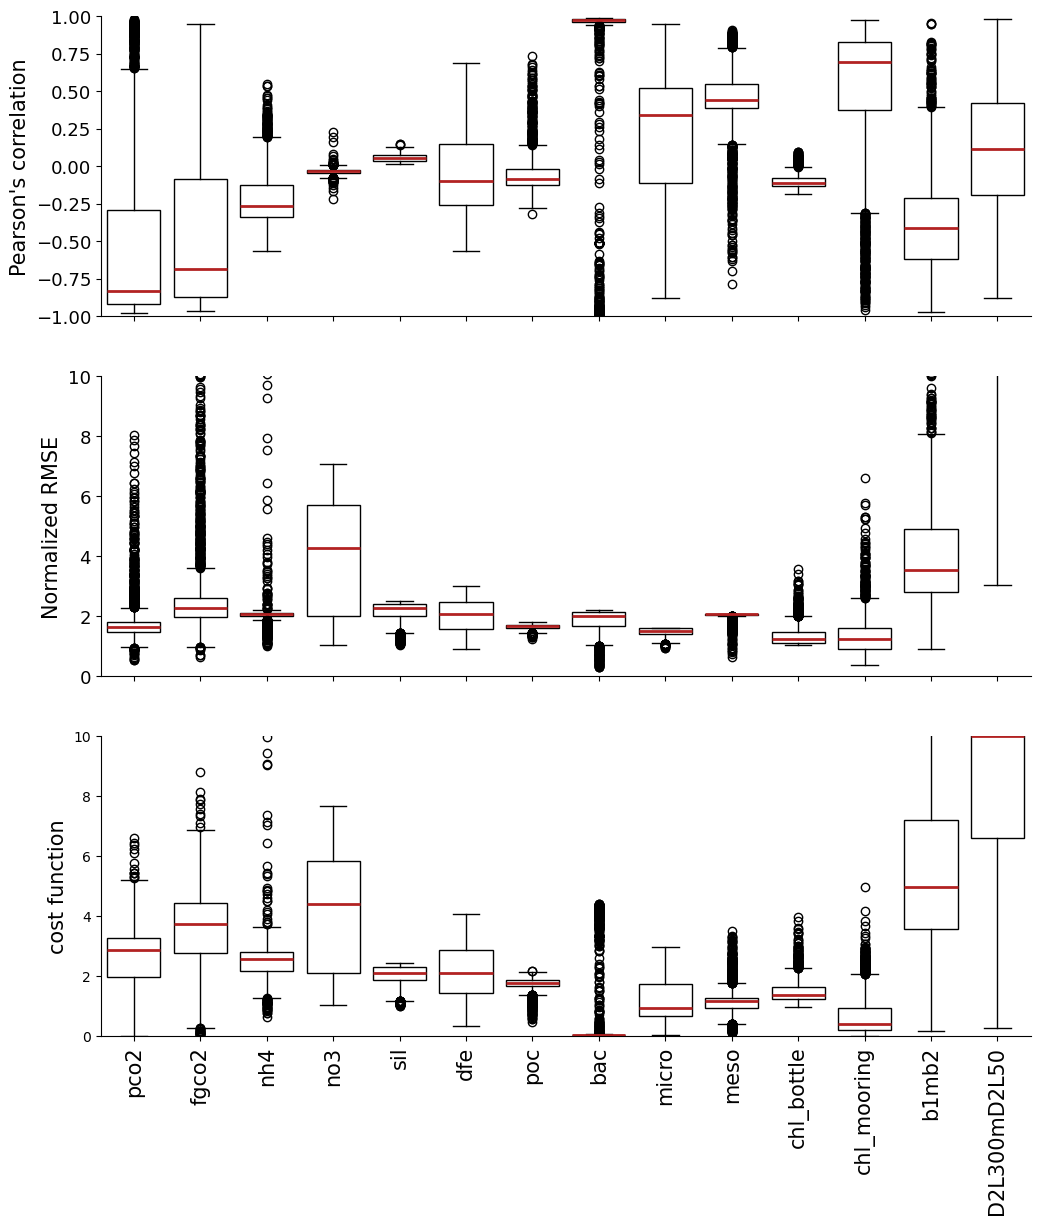

In [12]:
fstic = 13
fslab = 15

fig = plt.figure(figsize=(12,15))
gs = GridSpec(3,1)

ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[1,0])
ax3 = plt.subplot(gs[2,0])
ax1.spines[['top','right']].set_visible(False)
ax2.spines[['top','right']].set_visible(False)
ax3.spines[['top','right']].set_visible(False)
ax1.tick_params(labelsize=fstic, labelbottom=False)
ax2.tick_params(labelsize=fstic, labelbottom=False)
ax2.tick_params(labelsize=fstic)

box1 = ax1.boxplot(corr, positions=np.arange(0,len(targets),1), widths=0.8, patch_artist=True)
box2 = ax2.boxplot(nrmse, positions=np.arange(0,len(targets),1), widths=0.8, patch_artist=True)
box3 = ax3.boxplot(cost, positions=np.arange(0,len(targets),1), widths=0.8, patch_artist=True)

# Apply colors to each box
for patch in box1['boxes']:
    patch.set_facecolor('w')
for patch in box2['boxes']:
    patch.set_facecolor('w')
for patch in box3['boxes']:
    patch.set_facecolor('w')
for median in box1['medians']:
    median.set(color='firebrick', linewidth=2)
for median in box2['medians']:
    median.set(color='firebrick', linewidth=2)
for median in box3['medians']:
    median.set(color='firebrick', linewidth=2)

ax1.set_xlim(-0.5,len(targets)-1.5)
ax2.set_xlim(-0.5,len(targets)-1.5)
ax3.set_xlim(-0.5,len(targets)-1.5)

#ax2.set_yscale('log')

ax1.set_ylabel("Pearson's correlation", fontsize=fslab)
ax2.set_ylabel("Normalized RMSE", fontsize=fslab)
ax3.set_ylabel("cost function", fontsize=fslab)

ax3.set_xticks(np.arange(0,len(targets[0:-1]),1), targets[0:-1], fontsize=fslab, rotation=90)

plt.subplots_adjust(bottom=0.2)

ax1.set_ylim(-1,1)
ax2.set_ylim(0,10)
ax3.set_ylim(0,10)


In [13]:

os.chdir(wrkdir)
fig.savefig("../figures/sensitivity_analysis_corr_nrmse_costfunction_optimisation.png", dpi=300)
fig.savefig("../figures/sensitivity_analysis_corr_nrmse_costfunction_optimisation.pdf", dpi=300)
fig.savefig("../figures/sensitivity_analysis_corr_nrmse_costfunction_optimisation_transparent.png", dpi=300, transparent=True)


## Train a Gaussian Process Regression model on the output

### start a dask client cluster

In [14]:
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=56, threads_per_worker=1, memory_limit="16GB")
client  = Client(cluster)
client  # shows dashboard link


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 56
Total threads: 56,Total memory: 834.47 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35277,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46317,Total threads: 1
Dashboard: /proxy/43927/status,Memory: 14.90 GiB
Nanny: tcp://127.0.0.1:40997,


### train GPR on the normalized RMSE

In [15]:
%%time

### format the input data to the GPR model
X.columns = list(range(40))

tarcols = nrmse.columns

Y = np.zeros((2048, len(tarcols)))
for i, target in enumerate(tarcols):
    Y[:,i] = rmse[target]
    # Normalising RMSE values (RMSE - min(RMSE)/max(RMSE) - min(RMSE))
    Y[:,i]=(Y[:,i]-Y[:,i].min())/(Y[:,i].max()-Y[:,i].min())


CPU times: user 3.47 ms, sys: 9.17 ms, total: 12.6 ms
Wall time: 10.6 ms


In [16]:
%%time

targets = ['surface pCO$_2$', \
           'air-sea flux of CO$_2$', \
               'bottle NH$_4$', \
               'bottle NO$_3$', \
               'bottle Si(OH)$_4$', \
               'bottle dFe', \
               'bottle POC', \
               'bottle chlorophyll', \
               'mooring chlorophyll', \
               'B1 minus B2', \
               'D:L at 300m minus D:L at 50m']


CPU times: user 7 μs, sys: 22 μs, total: 29 μs
Wall time: 53.2 μs


In [17]:
n_vars   = len(targets)
n_params = len(X.columns)
N        = len(X)

print(n_vars, n_params, N)

11 40 2048


In [18]:
%%time

from sklearn.model_selection import KFold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning  # add this near the top
from sklearn.metrics import r2_score
from sklearn.base import clone
from joblib import Parallel, delayed, parallel_backend

import warnings
warnings.filterwarnings('ignore')

n_vars   = len(targets)
n_params = len(X.columns)
N        = len(X)

kf = KFold(n_splits=8, shuffle=True, random_state=42)
splits = list(kf.split(X))  # materialize once so workers can iterate

kernel = (ConstantKernel(1.0, (1e-3, 1e3)) *
          Matern(length_scale=np.ones(n_params),           # 1-D vector (ARD)
                 length_scale_bounds=(1e-3, 5.0), nu=1.5)
          + WhiteKernel(noise_level=1e-6,
                        noise_level_bounds=(1e-9, 1e-2)))

base_gpr = GaussianProcessRegressor(kernel=kernel,
                                    n_restarts_optimizer=5,
                                    random_state=42)

def fit_one_fold(i, f, tr, te):
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)  # if applicable
    est   = clone(base_gpr)
    est.fit(X.iloc[tr, :], Y[tr, i])
    y_hat = est.predict(X.iloc[te, :])
    r2    = r2_score(Y[te, i], y_hat)
    # return everything needed to assemble safely on the driver
    return (i, f, te, y_hat, Y[te, i], r2)

# run all (target, fold) jobs in parallel
with parallel_backend("dask"): 
    results = Parallel(prefer="processes", verbose=0)(
        delayed(fit_one_fold)(i, f, tr, te)
        for i in range(n_vars)
        for f, (tr, te) in enumerate(splits)
    )

# assemble on the driver (no race conditions)
GPR_score = np.zeros((len(splits), n_vars))
Y_PRED    = np.zeros((N, n_vars))
Y_TRUE    = np.zeros((N, n_vars))

for i, f, te, y_hat, y_true, r2 in results:
    Y_PRED[te, i]      = y_hat
    Y_TRUE[te, i]      = y_true
    GPR_score[f, i]    = r2

# per-target prints and overall R^2
for i in range(n_vars):
    print(i, targets[i], np.round(GPR_score[:, i], 3))

overall_r2 = [r2_score(Y_TRUE[:, i], Y_PRED[:, i]) for i in range(n_vars)]
print("GPR per-target R^2:", np.round(overall_r2, 3))
print("GPR mean R^2:", np.round(np.mean(overall_r2), 3))


0 surface pCO$_2$ [0.604 0.491 0.572 0.724 0.639 0.57  0.52  0.604]
1 air-sea flux of CO$_2$ [0.646 0.547 0.594 0.742 0.665 0.614 0.562 0.643]
2 bottle NH$_4$ [ 0.243 -0.396  0.323 -1.166  0.513  0.127  0.297  0.696]
3 bottle NO$_3$ [0.684 0.66  0.766 0.753 0.694 0.697 0.714 0.711]
4 bottle Si(OH)$_4$ [0.548 0.54  0.47  0.416 0.579 0.528 0.636 0.539]
5 bottle dFe [0.814 0.809 0.841 0.837 0.826 0.848 0.855 0.832]
6 bottle POC [0.722 0.738 0.627 0.692 0.67  0.661 0.715 0.706]
7 bottle chlorophyll [0.746 0.802 0.755 0.833 0.796 0.8   0.834 0.783]
8 mooring chlorophyll [0.768 0.719 0.714 0.714 0.716 0.764 0.768 0.677]
9 B1 minus B2 [0.545 0.448 0.643 0.473 0.479 0.236 0.482 0.403]
10 D:L at 300m minus D:L at 50m [0.652 0.707 0.58  0.614 0.618 0.638 0.643 0.564]
GPR per-target R^2: [0.596 0.63  0.251 0.71  0.533 0.832 0.692 0.799 0.733 0.498 0.626]
GPR mean R^2: 0.627
CPU times: user 10min 28s, sys: 6min 27s, total: 16min 55s
Wall time: 52min 59s


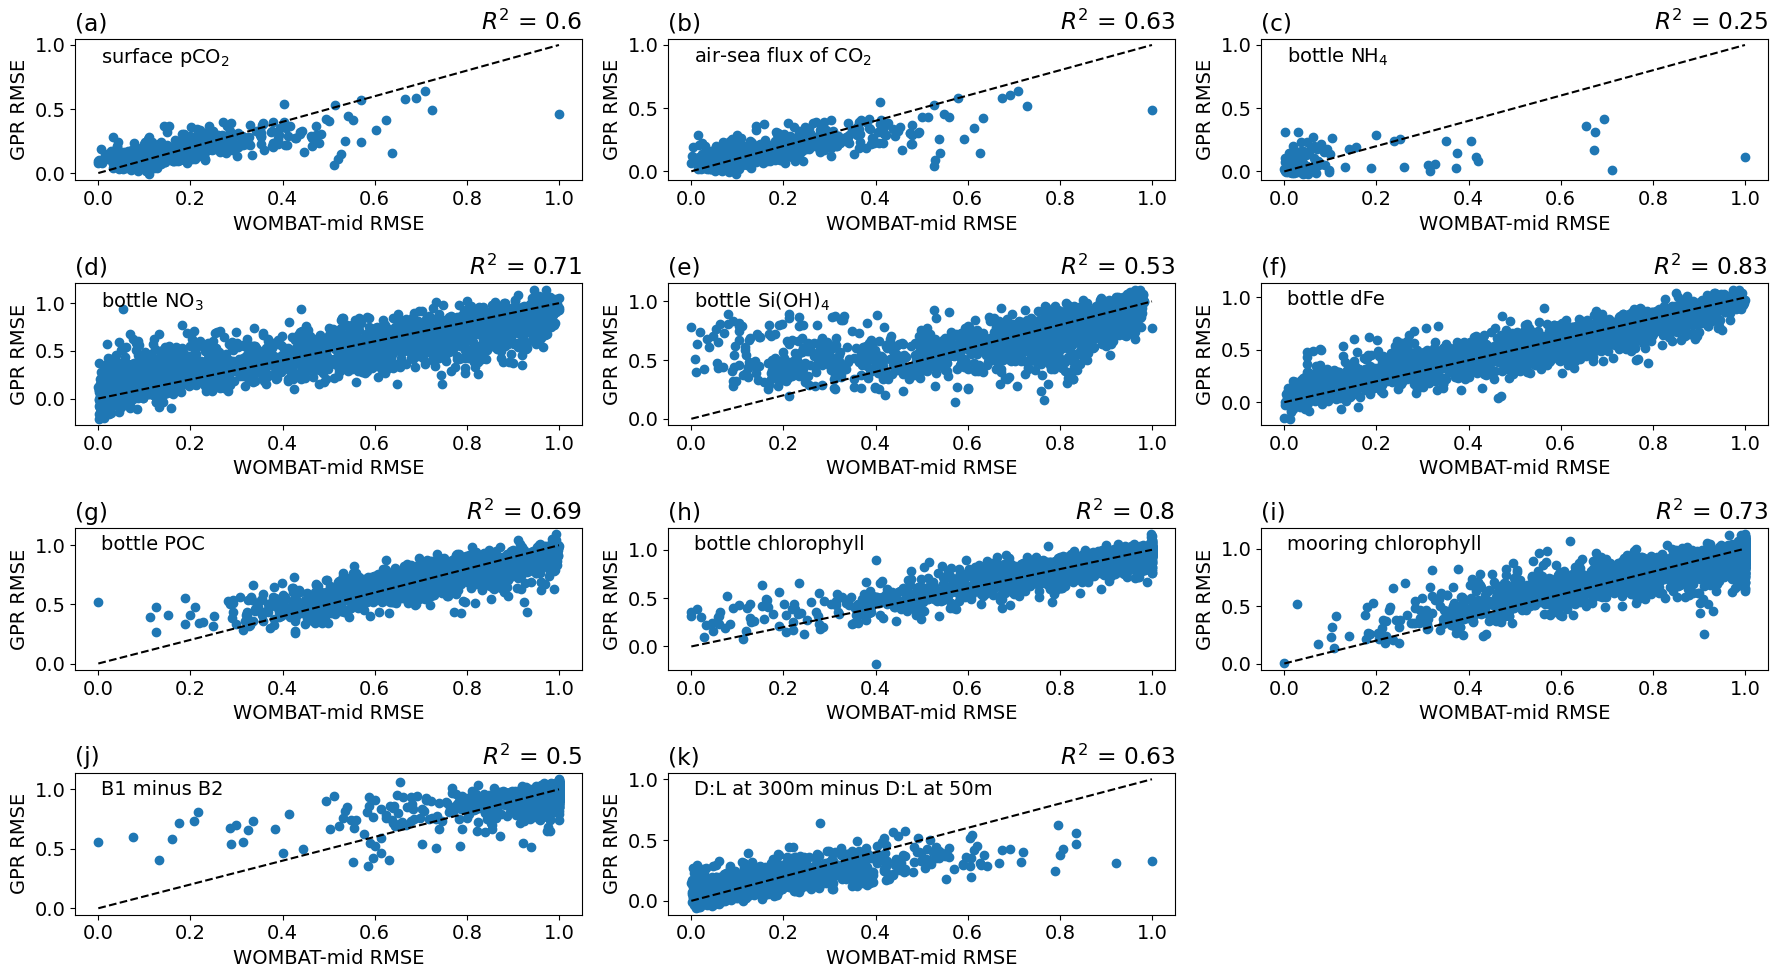

In [19]:

fig = plt.figure(figsize=(18,10))
plt.rc('font', size=14)    # fontsize of the all text
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('xtick', labelsize=14)
abc = ['(a) ','(b) ','(c) ',\
       '(d) ','(e) ','(f) ',\
       '(g) ','(h) ','(i) ',\
       '(j) ','(k) ']

for i in range(len(targets)):
    #ax = fig.add_subplot(2,3,i+1)
    ax = fig.add_subplot(4,3,i+1)
    ax.plot((np.min(Y_TRUE[:,i]),np.max(Y_TRUE[:,i])), (np.min(Y_TRUE[:,i]), np.max(Y_TRUE[:,i])), 'k--')
    ax.scatter(Y_TRUE[:,i],Y_PRED[:,i])
    ax.set_title(abc[i], loc='left')
    ax.text(0.05,0.95, targets[i], va='top', ha='left', transform=ax.transAxes)
    ax.set_title('$R^2$ = '+str(round(r2_score(Y_TRUE[:,i],Y_PRED[:,i]),2)),
               loc='right')
    ax.set_xlabel(r'WOMBAT-mid RMSE')
    ax.set_ylabel('GPR RMSE')
    #ax.set_xlim(0,1)
    #ax.set_ylim(0,1)

plt.tight_layout()
fig.savefig('../figures/sensitivity_analysis_GPRaccuracy_RMSEnormRange_2048_optimisation.png', dpi=300,bbox_inches='tight')


### calculate the GPR accuracy at different numbers of experimental samples

In [22]:
%%time

import numpy as np
import pandas as pd
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.metrics import r2_score
from sklearn.base import clone
from sklearn.model_selection import KFold
from joblib import Parallel, delayed, parallel_backend

warnings.filterwarnings('ignore')

# --- setup ---
n_vars   = len(targets)
n_params = len(X.columns)
N_total  = len(X)
N_list   = [64, 128, 256, 512, 1024]   # number of samples to test
n_splits = 8

GPR_score = np.zeros((n_vars, len(N_list), n_splits))

# --- base kernel and model ---
base_kernel = (ConstantKernel(1.0, (1e-3, 1e3)) *
               Matern(length_scale=np.ones(n_params),
                      length_scale_bounds=(1e-3, 5.0), nu=1.5)
               + WhiteKernel(noise_level=1e-6,
                             noise_level_bounds=(1e-9, 1e-2)))

base_gpr = GaussianProcessRegressor(
    kernel=base_kernel,
    n_restarts_optimizer=5,
    random_state=42
)

# --- worker function ---
def fit_one_fold(i, j, f, tr, te, N_sub):
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    est = clone(base_gpr)
    X_tr, X_te = X.iloc[tr, :], X.iloc[te, :]
    y_tr, y_te = Y[tr, i], Y[te, i]

    est.fit(X_tr, y_tr)
    y_hat = est.predict(X_te)
    r2 = r2_score(y_te, y_hat)
    return (i, j, f, N_sub, r2)

# --- main loop (parallelised folds and targets) ---
with parallel_backend("dask"):  # or "loky" if no Dask client
    results = Parallel(prefer="processes", verbose=0)(
        delayed(fit_one_fold)(i, j, f, tr, te, N_sub)
        for j, N_sub in enumerate(N_list)
        for i in range(n_vars)
        for f, (tr, te) in enumerate(
            KFold(n_splits=n_splits, shuffle=True, random_state=42).split(range(N_sub))
        )
    )

# --- assemble results ---
for i, j, f, N_sub, r2 in results:
    GPR_score[i, j, f] = r2

# --- report results ---
for i in range(n_vars):
    for j, N_sub in enumerate(N_list):
        mean_r2 = np.nanmean(GPR_score[i, j, :])
        print(f"{targets[i]:<25s}  N={N_sub:<5d}  mean R²={mean_r2:.3f}")


surface pCO$_2$            N=64     mean R²=-1.550
surface pCO$_2$            N=128    mean R²=-0.214
surface pCO$_2$            N=256    mean R²=0.319
surface pCO$_2$            N=512    mean R²=0.316
surface pCO$_2$            N=1024   mean R²=0.517
air-sea flux of CO$_2$     N=64     mean R²=-1.051
air-sea flux of CO$_2$     N=128    mean R²=0.104
air-sea flux of CO$_2$     N=256    mean R²=0.378
air-sea flux of CO$_2$     N=512    mean R²=0.382
air-sea flux of CO$_2$     N=1024   mean R²=0.563
bottle NH$_4$              N=64     mean R²=-3.571
bottle NH$_4$              N=128    mean R²=-1.316
bottle NH$_4$              N=256    mean R²=-0.535
bottle NH$_4$              N=512    mean R²=-0.631
bottle NH$_4$              N=1024   mean R²=-0.018
bottle NO$_3$              N=64     mean R²=-1.560
bottle NO$_3$              N=128    mean R²=-0.223
bottle NO$_3$              N=256    mean R²=0.347
bottle NO$_3$              N=512    mean R²=0.570
bottle NO$_3$              N=1024   mean

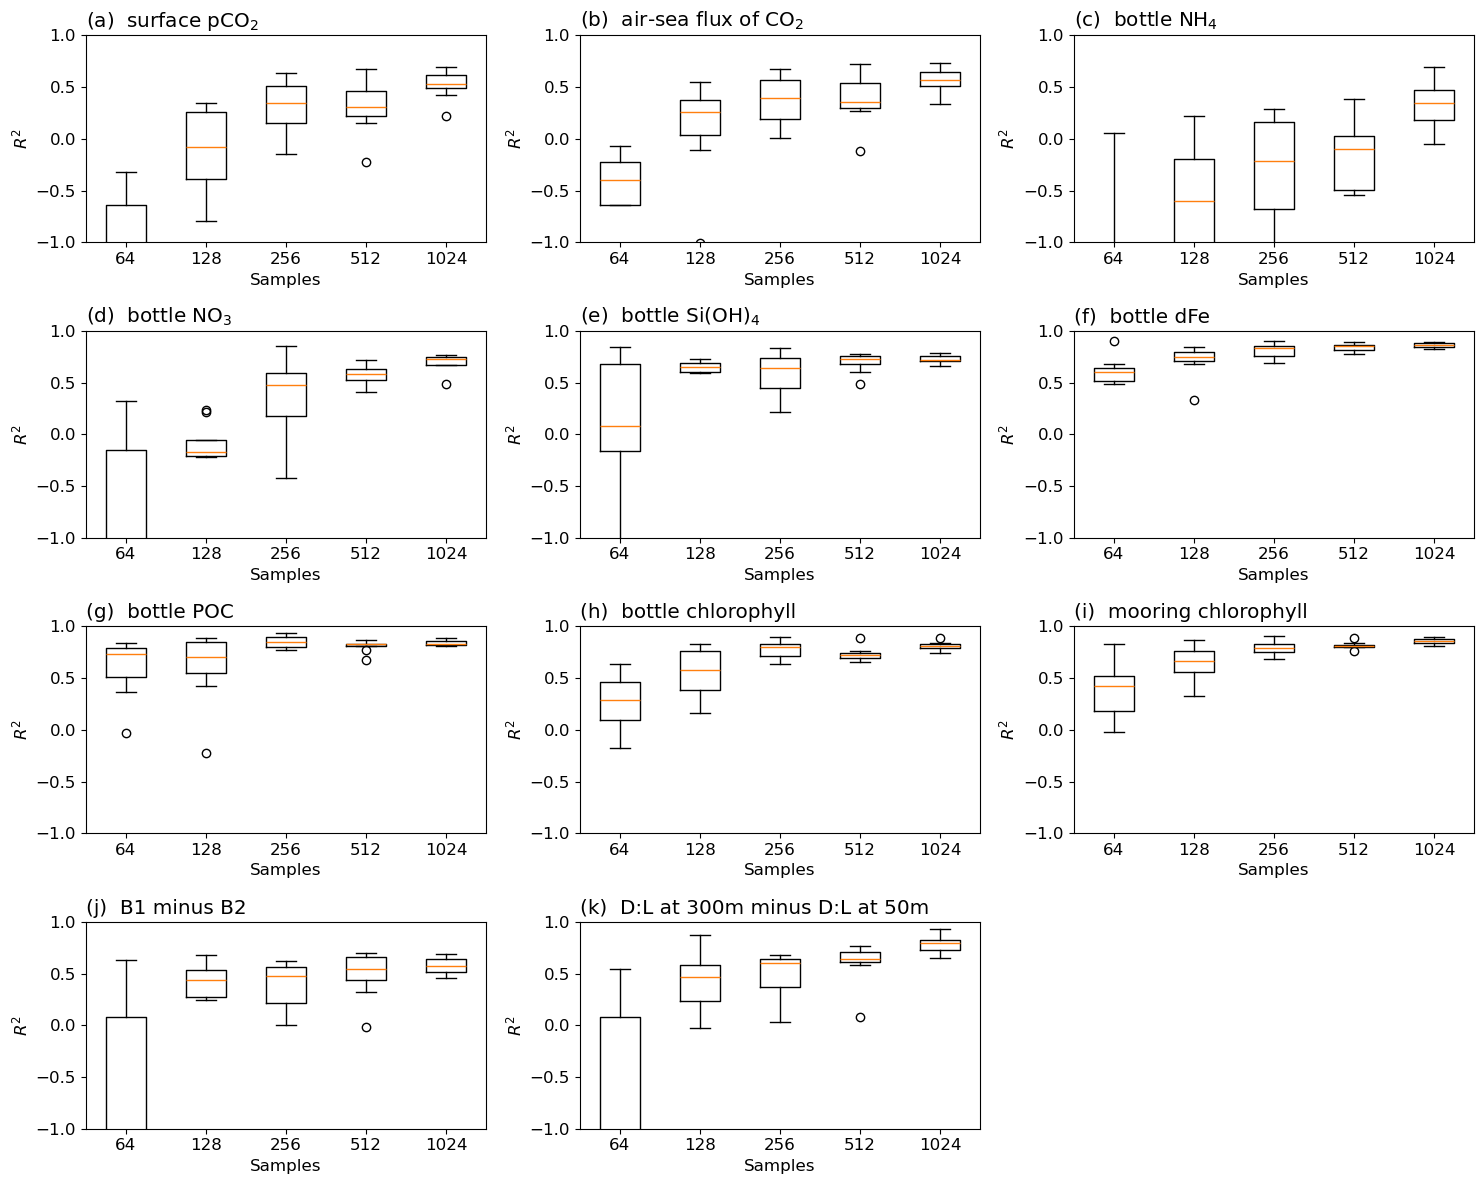

In [23]:
fig = plt.figure(figsize=(15,12))
plt.rc('font', size=12)    # fontsize of the all text
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('xtick', labelsize=12)
abc = ['(a) ','(b) ','(c) ','(d) ','(e) ','(f) ','(g) ','(h) ','(i) ','(j) ','(k) ']
for i in range(len(targets)):
    axs = fig.add_subplot(4,3,i+1)
    axs.boxplot(GPR_score[i,0:5,:].T)
    axs.set_title(abc[i] + " " + targets[i], loc='left')
    #axs.text(0.5,1.02, targets[i], va='bottom', ha='center', transform=axs.transAxes, rotation=0)
    axs.set_ylabel('$R^2$')
    axs.set_xlabel('Samples')
    axs.set_xticklabels(['64','128','256','512','1024'])
    axs.set_ylim(-1.,1.0)
plt.subplots_adjust(wspace=0.4,hspace=0.4)
plt.tight_layout()
fig.savefig('../figures/sensitivity_analysis_GPRsensitivity_RMSEnormRange_optimisation.png', dpi=300,bbox_inches='tight')

### Do Sobol' sensitivity analysis

#### but only on targets that had an R2 score > 0.6

In [24]:
# --- report results ---
N_sub = 2048
j = -1
for i in range(n_vars):
    mean_r2 = np.nanmean(GPR_score[i, j, :])
    print(f"{targets[i]:<25s}  N={N_sub:<5d}  mean R²={mean_r2:.3f}")

surface pCO$_2$            N=1024   mean R²=0.517
air-sea flux of CO$_2$     N=1024   mean R²=0.563
bottle NH$_4$              N=1024   mean R²=-0.018
bottle NO$_3$              N=1024   mean R²=0.694
bottle Si(OH)$_4$          N=1024   mean R²=0.724
bottle dFe                 N=1024   mean R²=0.864
bottle POC                 N=1024   mean R²=0.839
bottle chlorophyll         N=1024   mean R²=0.806
mooring chlorophyll        N=1024   mean R²=0.855
B1 minus B2                N=1024   mean R²=0.575
D:L at 300m minus D:L at 50m  N=1024   mean R²=0.781


In [20]:
%%time

from SALib.sample import saltelli

# Define the problem with 100 parameters
problem = {
    'num_vars': len(X.columns),
    'names': [f'P{i+1}' for i in range(len(X.columns))],
    'bounds': [[0, 1]] * len(X.columns)
}

# Generate the Saltelli sampling (1024 base samples, including 2nd-order terms)
param_values = saltelli.sample(problem, 2048, calc_second_order=True)

print(param_values.shape)
print("Max of first parameter:", max(param_values[:, 0]))


(167936, 40)
Max of first parameter: 0.999755859375
CPU times: user 2.92 s, sys: 83.9 ms, total: 3 s
Wall time: 2.94 s


In [21]:
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=28, threads_per_worker=4, memory_limit="32GB")
client  = Client(cluster)
client  # shows dashboard link


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/39939/status,
Dashboard: /proxy/39939/status,Workers: 28
Total threads: 112,Total memory: 834.47 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38815,Workers: 0
Dashboard: /proxy/39939/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40459,Total threads: 4
Dashboard: /proxy/42233/status,Memory: 29.80 GiB
Nanny: tcp://127.0.0.1:40689,


In [ ]:
%%time

# --- base kernel and model ---
base_kernel = (ConstantKernel(1.0, (1e-3, 1e3)) *
               Matern(length_scale=np.ones(n_params),
                      length_scale_bounds=(1e-3, 5.0), nu=1.5)
               + WhiteKernel(noise_level=1e-6,
                             noise_level_bounds=(1e-9, 1e-2)))

base_gpr = GaussianProcessRegressor(
    kernel=base_kernel,
    n_restarts_optimizer=5,
    random_state=42
)


def sobol_for_target(i):
    """Train GPR for one target variable and compute Sobol indices."""
    import warnings
    warnings.filterwarnings("ignore")
    y = Y[:, i]
    model = gaussian_process.GaussianProcessRegressor(kernel=base_kernel, random_state=42)
    model.fit(X, y)
    y_hat = model.predict(param_values)
    Si = sobol.analyze(problem, y_hat, parallel=False, print_to_console=False)
    return (i, Si['S1'], Si['ST'], Si['S2'])

# --- parallel execution ---
with parallel_backend("dask"):
    results_sobol = Parallel(prefer="processes", verbose=10)(
        delayed(sobol_for_target)(i) for i in range(n_vars)
    )



[Parallel(n_jobs=-1)]: Using backend DaskDistributedBackend with 112 concurrent workers.


In [27]:
# --- gather results ---
s1 = np.zeros((n_vars, n_params))
st = np.zeros((n_vars, n_params))
s2 = np.zeros((n_vars, n_params, n_params))

for i, S1, ST, S2 in results_sobol:
    s1[i, :] = S1
    st[i, :] = ST
    s2[i, :, :] = S2
    print(f"Target {i}: mean ST = {np.nanmean(ST):.3f}")

print("\nDone computing Sobol indices for all targets.")


Target 0: mean ST = 0.043
Target 1: mean ST = 0.042
Target 2: mean ST = 0.040
Target 3: mean ST = 0.042
Target 4: mean ST = 0.035
Target 5: mean ST = 0.031
Target 6: mean ST = 0.032
Target 7: mean ST = 0.033
Target 8: mean ST = 0.032
Target 9: mean ST = 0.039
Target 10: mean ST = 0.036

Done computing Sobol indices for all targets.


In [28]:
df = pd.DataFrame(data=st,
                    index=targets,
                    columns=problem['names'])
df_t = df.T
df_t = (df_t-df_t.min())/(df_t.max()-df_t.min())
df = df_t.T
df


,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,...,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40
surface pCO$_2$,0.189623,0.728151,0.087313,0.092435,0.001968,0.004241,0.012015,0.034245,0.033179,0.000626,...,0.003353,0.000329,0.003797,0.004931,1.000000,0.001588,0.080287,0.021615,0.560505,0.031239
air-sea flux of CO$_2$,0.168185,0.683990,0.074323,0.091735,0.002105,0.003181,0.010668,0.022420,0.030516,0.000791,...,0.003329,0.000306,0.005533,0.005058,1.000000,0.001188,0.072677,0.013623,0.552883,0.037874
bottle NH$_4$,0.000471,0.001327,0.000344,0.001201,0.000556,0.003842,0.090822,0.000184,0.000168,0.000404,...,0.000072,0.000020,0.000244,0.004413,1.000000,0.000153,0.000305,0.045867,0.094839,0.000178
bottle NO$_3$,0.004475,0.038364,0.001365,0.071741,0.006205,0.044038,0.003017,0.004600,0.002060,0.000559,...,0.019770,0.001096,0.001002,0.000449,1.000000,0.001239,0.041370,0.016568,0.739009,0.028633
bottle Si(OH)$_4$,0.001609,0.029249,0.000230,0.121815,0.000312,0.002051,0.022059,0.011897,0.060923,0.062655,...,0.007364,0.000453,0.009634,0.076978,0.067066,0.006239,0.001455,0.008167,0.066984,0.009128
bottle dFe,0.000578,0.010877,0.000222,0.013105,0.000090,0.016153,0.001402,0.004950,0.007709,0.002075,...,0.069328,0.120922,1.000000,0.001655,0.103697,0.000000,0.002818,0.001482,0.064667,0.013447
bottle POC,0.026416,0.236094,0.003365,0.028149,0.014941,0.031341,0.001024,0.353913,0.001288,0.001537,...,0.004459,0.002579,0.005160,0.025848,0.632895,0.000109,0.028001,0.004758,0.277534,0.053567
bottle chlorophyll,0.041805,0.273478,0.011374,0.017258,0.001727,0.007319,0.005397,0.018774,0.000616,0.001184,...,0.001720,0.000735,0.004889,0.002984,1.000000,0.027355,0.049363,0.001648,0.594864,0.363636
mooring chlorophyll,0.057028,0.488178,0.015012,0.037191,0.001705,0.058516,0.007324,0.165095,0.004590,0.001067,...,0.024795,0.003372,0.028354,0.005891,0.550787,0.000000,0.003713,0.000395,0.291101,0.013203
B1 minus B2,0.005907,0.058559,0.006936,0.032433,0.001514,0.046605,0.000934,0.007201,0.000000,0.000348,...,0.006714,0.040443,0.000419,0.014168,0.066990,0.003516,0.001740,0.001436,0.038229,0.002326


In [31]:
os.getcwd()

'/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data'

In [33]:
tmp = pd.read_excel("apriori_parameter_ranges_SOTSexps.xlsx", sheet_name="parameter_ranges")
tmp = tmp[tmp["optimisation?"]==1]
tmp = tmp.drop(["units", "References", "sensitivity analysis?", "optimisation?", "parameter number"], axis=1)
tmp = tmp.set_index("WOMBAT-full")
param_names = tmp.index
np.array(list(param_names))

array(['alphabio_phy', 'abioa_phy', 'bbioa_phy', 'abioa_dia', 'bbioh',
       'phykf', 'phymaxqc', 'phylmor', 'diamaxqs', 'diaVmaxs', 'dialmor',
       'overflow', 'zooCingest', 'zooCassim', 'zooeps', 'zprefdia',
       'zoolmor', 'mesCassim', 'meseps', 'mprefphy', 'meslmor', 'mesqmor',
       'mespreyswitch', 'detqrem', 'ldetphi', 'phyrad0', 'diarad0',
       'zoorad0', 'phybiot', 'diabiot', 'dfefloor', 'kscav_dfe',
       'kcoag_dfe', 'bsi_alpha', 'aoalmor', 'pbac_alpha', 'lbac_alpha',
       'lbac_beta', 'baclmor', 'bacqmor'], dtype='<U13')

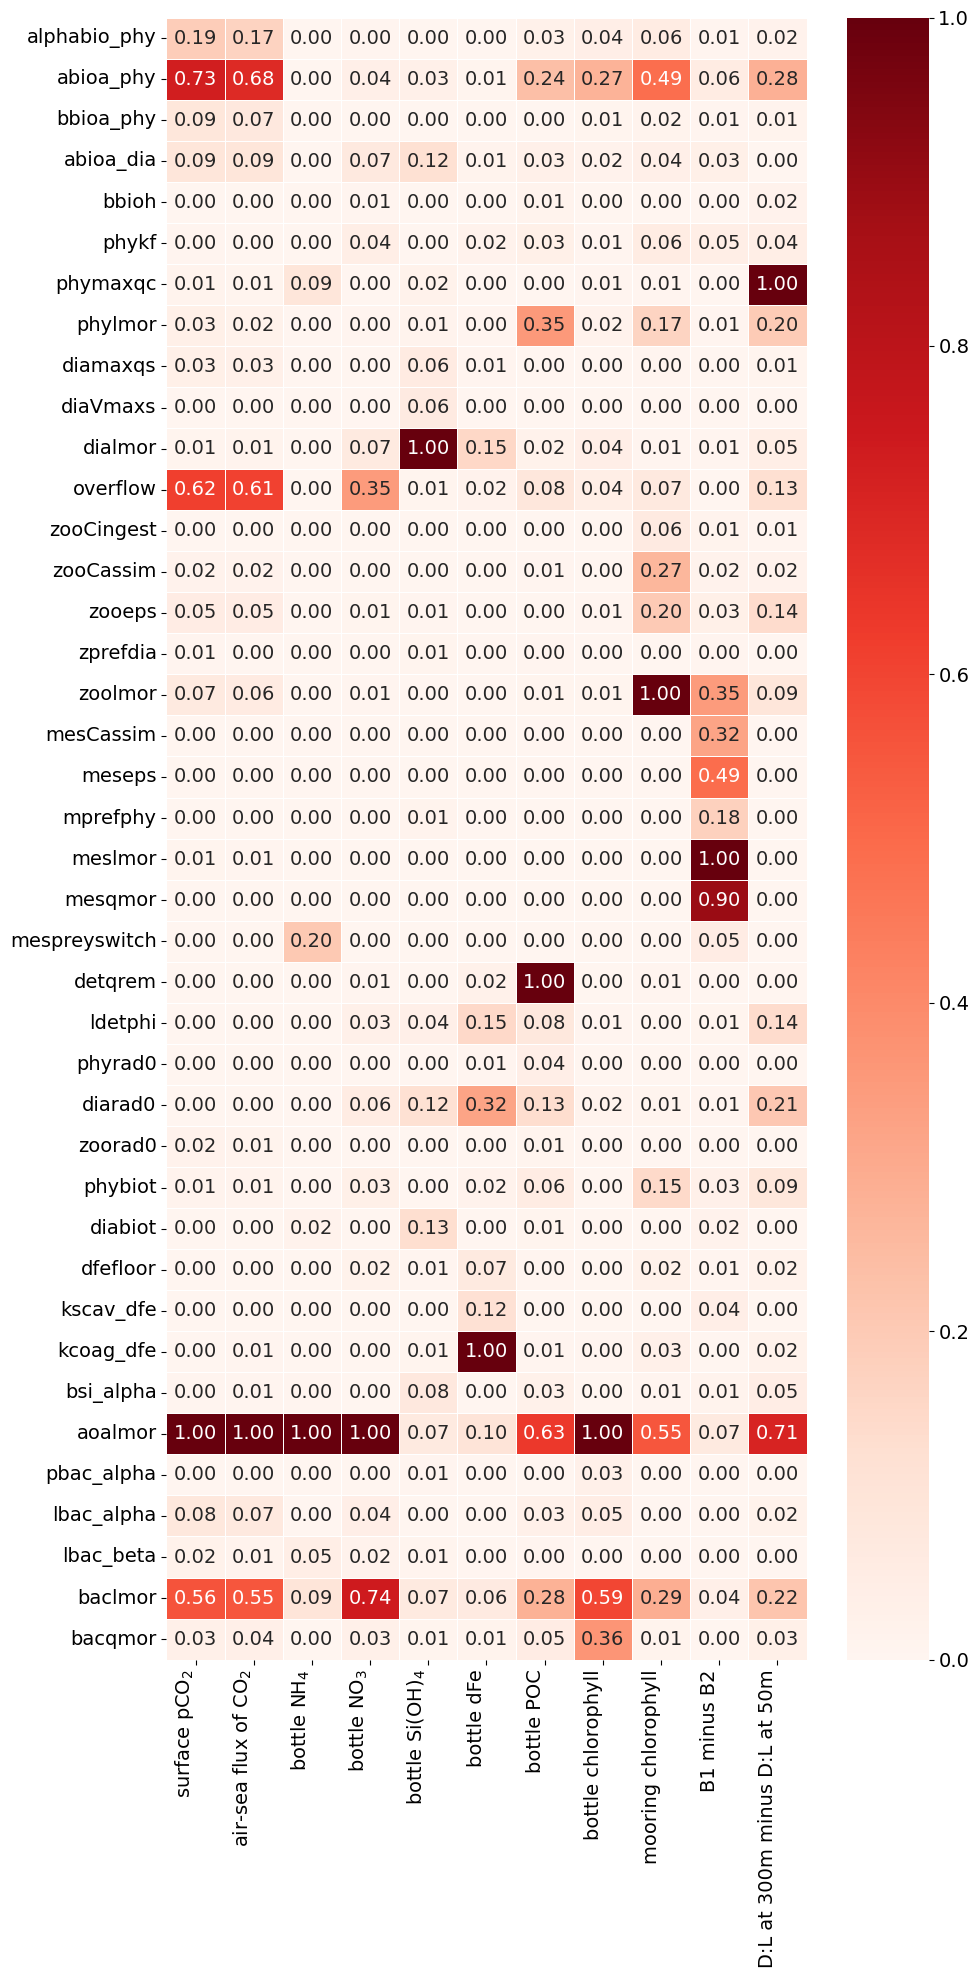

In [34]:
fig = plt.figure(figsize=(10,20))
gs = GridSpec(1,1)

ax = plt.subplot(gs[0])
ax = sns.heatmap(df.T,cmap="Reds",linewidths=.5, annot=True,fmt=".2f")
plt.xticks(rotation='horizontal')
ax.set_xticklabels(targets, rotation=90, fontsize=14, ha='right')
ax.set_yticklabels(np.array(list(param_names)), fontsize=14, ha='right')
plt.yticks(rotation='horizontal')
plt.tight_layout()


In [35]:
os.getcwd()
fig.savefig('../figures/sensitivity_analysis_heatmap_40parameters_2048exps.png', dpi=300,bbox_inches='tight')


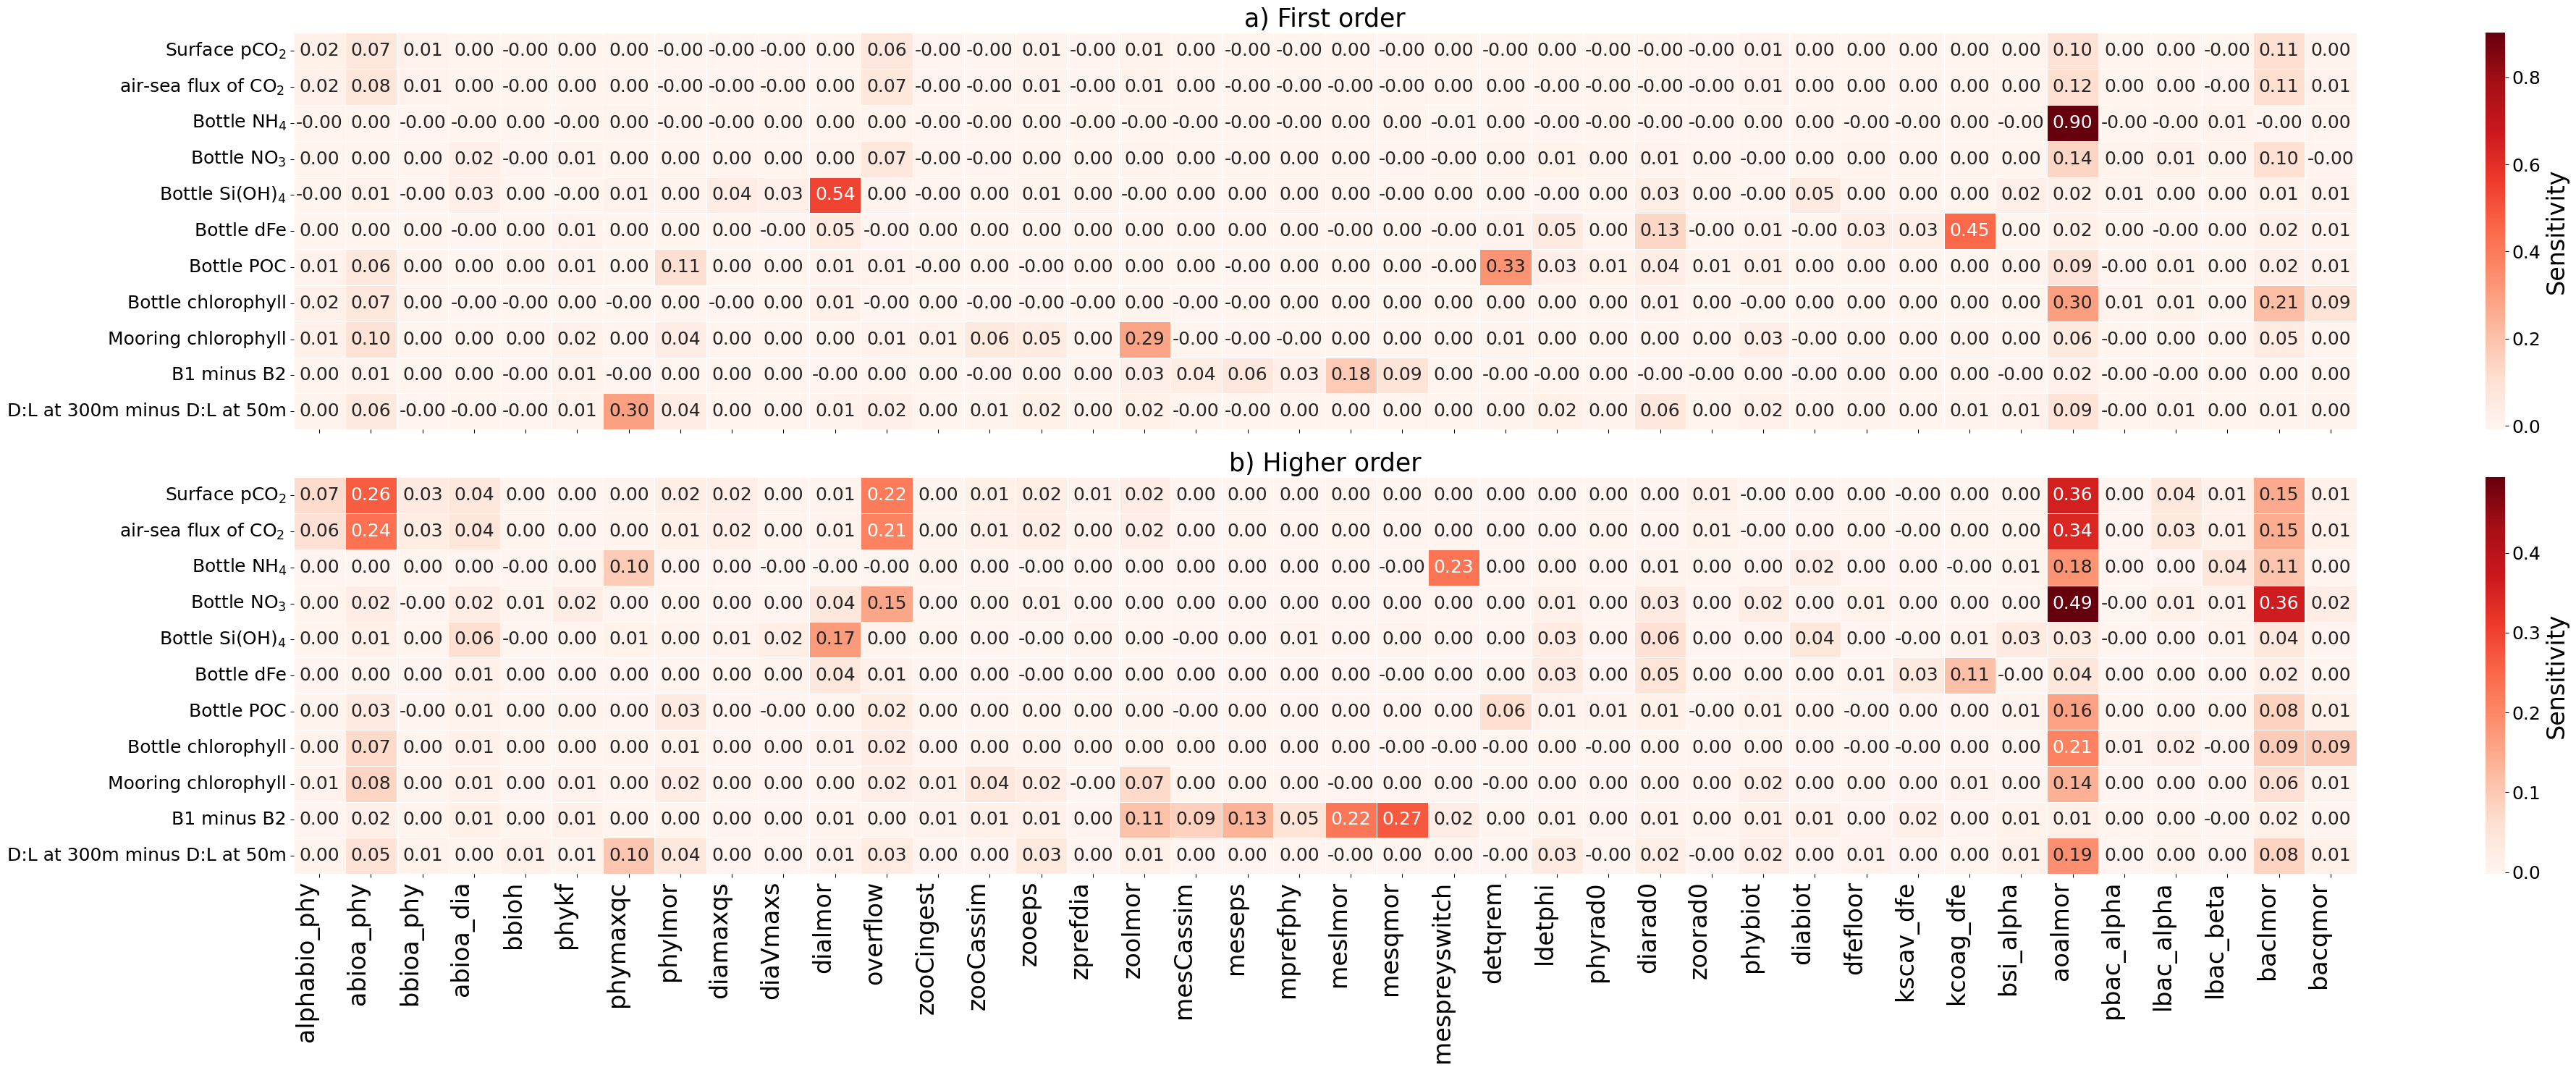

In [36]:
var_names = [
    'Surface pCO$_2$', 
    'air-sea flux of CO$_{2}$ ', 
    'Bottle NH$_4$', 
    'Bottle NO$_3$',
    'Bottle Si(OH)$_4$', 
    'Bottle dFe', 
    'Bottle POC', 
    'Bottle chlorophyll',
    'Mooring chlorophyll',
    'B1 minus B2',
    'D:L at 300m minus D:L at 50m'
]

# First dataset processing
df1 = pd.DataFrame(data=s1, index=var_names, columns=problem['names'])
df_t1 = df1.T
#df_t1 = (df_t1 - df_t1.min()) / (df_t1.max() - df_t1.min())
df1 = df_t1.T

# Second dataset processing
df2 = pd.DataFrame(data=(st - s1), index=var_names, columns=problem['names'])
df_t2 = df2.T
#df_t2 = (df_t2 - df_t2.min()) / (df_t2.max() - df_t2.min())
df2 = df_t2.T

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(40, 15))

# Plot first heatmap (subplot a)
hmap1 = sns.heatmap(df1, cmap="Reds", linewidths=0.5, annot=True, fmt=".2f", ax=axes[0], annot_kws={"size": 18})
#axes[0].set_xticklabels(param_names, rotation=90, fontsize=18, ha='right')
axes[0].set_title('a) First order', fontsize=25)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=18)
axes[0].set_xticklabels(axes[0].get_xticklabels(), fontsize=24)
axes[0].tick_params(labelbottom=False)

# Plot second heatmap (subplot b)
hmap2 = sns.heatmap(df2, cmap="Reds", linewidths=0.5, annot=True, fmt=".2f", ax=axes[1], annot_kws={"size": 18})
axes[1].set_xticklabels(param_names, rotation=90, fontsize=18, ha='right')
axes[1].set_title('b) Higher order', fontsize=25)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=18)
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=24)

cbar1 = hmap1.collections[0].colorbar
cbar2 = hmap2.collections[0].colorbar
cbar1.set_label('Sensitivity', fontsize=24)
cbar1.ax.tick_params(labelsize=18)
cbar2.set_label('Sensitivity', fontsize=24)
cbar2.ax.tick_params(labelsize=18)

# Adjust layout
plt.tight_layout()
fig.savefig('../figures/sensitivity_analysis_SAresult_RMSEnormRange_2048exps_optimisation.png', dpi=300, bbox_inches='tight')
fig.savefig('../figures/sensitivity_analysis_SAresult_RMSEnormRange_2048exps_optimisation.pdf', dpi=300, bbox_inches='tight')


#### check whether the MCMC chain is long enough and whether walkers are moving acceptably

- **tau**: is the estimated integrated autocorrelation time for each parameter.
- **required steps**: is the conservative emcee rule of thumb.
- **actual steps**: the number of steps we performed.
- **ratio**: says how many autocorrelation times your chain spans.
- **mean acceptance**: tells you how often proposed moves are accepted.

In [ ]:
print("max tau:", np.max(tau))
print("required steps:", 50 * np.max(tau))
print("actual steps:", opt_chains.shape[0])
print("ratio:", opt_chains.shape[0] / np.max(tau))
print("mean acceptance:", np.mean(sampler.acceptance_fraction))

#### Check whether the chain is still drifting

In [ ]:
log_probs = sampler.get_log_prob()

plt.figure(figsize=(10, 4))
plt.plot(log_probs, alpha=0.3)
plt.xlabel("step")
plt.ylabel("log probability")
plt.show()

#### Check parameter traces